In [3]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


## Load the Dataset

The merged language dataset is loaded into a DataFrame. The table is displayed to inspect the available text and language labels.

In [4]:
import pandas as pd
df = pd.read_csv("merged_dataset.csv")
df

,Text,Language
0,klement gottwaldi surnukeha palsameeriti ning ...,Estonian
1,sebes joseph pereira thomas på eng the jesuit...,Swedish
2,ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...,Thai
3,விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...,Tamil
4,de spons behoort tot het geslacht haliclona en...,Dutch
...,...,...
32332,ನಿಮ್ಮ ತಪ್ಪು ಏನು ಬಂದಿದೆಯೆಂದರೆ ಆ ದಿನದಿಂದ ನಿಮಗೆ ಒ...,Kannada
32333,ನಾರ್ಸಿಸಾ ತಾನು ಮೊದಲಿಗೆ ಹೆಣಗಾಡುತ್ತಿದ್ದ ಮಾರ್ಗಗಳನ್...,Kannada
32334,ಹೇಗೆ ' ನಾರ್ಸಿಸಿಸಮ್ ಈಗ ಮರಿಯನ್ ಅವರಿಗೆ ಸಂಭವಿಸಿದ ಎ...,Kannada
32335,ಅವಳು ಈಗ ಹೆಚ್ಚು ಚಿನ್ನದ ಬ್ರೆಡ್ ಬಯಸುವುದಿಲ್ಲ ಎಂದು ...,Kannada


### Check for Missing Values

This check identifies missing entries before preprocessing so incomplete records can be handled appropriately.

In [5]:
missing_values = df.isnull().sum()
missing_values

,0
Text,0
Language,0


### Check for Duplicate Records

Duplicate rows are counted to understand whether repeated samples are present in the original dataset.


In [6]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 207


### Inspect the Language Classes

The unique language labels are listed to confirm which languages are represented and how many classes the dataset contains.

In [7]:
# Get the unique languages from the 'Language' column of the original dataframe
original_languages = df['Language'].unique()

# Sort the languages alphabetically for better readability
original_languages.sort()

print("Languages present in merged_dataset.csv:")
for lang in original_languages:
    print(f"- {lang}")

print(f"\nTotal count of unique languages in merged_dataset.csv: {len(original_languages)}")

Languages present in merged_dataset.csv:
- Arabic
- Chinese
- Danish
- Dutch
- English
- Estonian
- French
- German
- Greek
- Hindi
- Indonesian
- Italian
- Japanese
- Kannada
- Korean
- Latin
- Malayalam
- Persian
- Portugeese
- Portugese
- Pushto
- Romanian
- Russian
- Spanish
- Swedish
- Sweedish
- Tamil
- Thai
- Turkish
- Urdu

Total count of unique languages in merged_dataset.csv: 30


# Data Preprocessing

### Clean and Encode the Data

Duplicates are removed, inconsistent language spellings are standardized, text is normalized, and language names are converted into numeric labels. The cleaned dataset is then saved as **cleaned_encoded_dataset** for the next stage.

In [8]:
#Data Preprocessing
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import re

# Load the dataset
data = pd.read_csv('merged_dataset.csv')

# Step 1: Remove duplicates
data_cleaned = data.drop_duplicates().copy()

# Step 2: Merge misspelled duplicate labels (they came from different sources)
data_cleaned['Language'] = data_cleaned['Language'].replace({
    'Portugeese': 'Portuguese',
    'Portugese': 'Portuguese',
    'Sweedish': 'Swedish'
})

# Step 3: Clean text (lowercase, remove ALL punctuation and numbers)
def cleaned_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)   # remove ALL punctuation
    text = re.sub(r'\d+', '', text)       # remove numbers
    text = re.sub(r'\s+', ' ', text)      # collapse spaces left behind
    return text.strip()

data_cleaned['Text'] = data_cleaned['Text'].apply(cleaned_text)

# Step 4: Encode the 'Language' column
le = LabelEncoder()
data_cleaned['Language'] = le.fit_transform(data_cleaned['Language'])

# Step 5: Save the cleaned and encoded dataset
data_cleaned.to_csv('cleaned_encoded_dataset.csv', index=False)

print("Number of classes:", len(le.classes_))
data_cleaned

Number of classes: 28


,Text,Language
0,klement gottwaldi surnukeha palsameeriti ning ...,5
1,sebes joseph pereira thomas på eng the jesuits...,23
2,ถนนเจรญกรง อกษรโรมน thanon charoen krung เรมตง...,25
3,வசகபபடடனம தமழசசஙகதத இநதப பததரகவசகபபடடன ஆசரயர ச...,24
4,de spons behoort tot het geslacht haliclona en...,3
...,...,...
32332,ನಮಮ ತಪಪ ಏನ ಬದದಯದರ ಆ ದನದದ ನಮಗ ಒಳಳಯದನನ ನಡಣ,13
32333,ನರಸಸ ತನ ಮದಲಗ ಹಣಗಡತತದದ ಮರಗಗಳನನ ಬದಲಯಸದಳ ಆದರ ನಧನವ...,13
32334,ಹಗ ನರಸಸಸಮ ಈಗ ಮರಯನ ಅವರಗ ಸಭವಸದ ಎಲಲವನನ ಹಳದ ಮತತ ಅವ...,13
32335,ಅವಳ ಈಗ ಹಚಚ ಚನನದ ಬರಡ ಬಯಸವದಲಲ ಎದ ನನ ess ಹಸದದನ,13


### Validate the Cleaned Dataset

Missing-value counts are checked again after preprocessing to verify that the cleaned data is ready for modeling.


In [9]:
unique_values = data_cleaned.isnull().sum()
unique_values

,0
Text,0
Language,0


### Verify Punctuation Removal

This check confirms that punctuation has been removed from the cleaned text across the language classes.


In [10]:
df_c = pd.read_csv('cleaned_encoded_dataset.csv')
df_c['has_punct'] = df_c['Text'].astype(str).str.contains(r'[.,!?-]')
print((df_c.groupby('Language')['has_punct'].mean() * 100).round(1).rename(index=lambda i: le.classes_[i]))

Language
Arabic        0.0
Chinese       0.0
Danish        0.0
Dutch         0.0
English       0.0
Estonian      0.0
French        0.0
German        0.0
Greek         0.0
Hindi         0.0
Indonesian    0.0
Italian       0.0
Japanese      0.0
Kannada       0.0
Korean        0.0
Latin         0.0
Malayalam     0.0
Persian       0.0
Portuguese    0.0
Pushto        0.0
Romanian      0.0
Russian       0.0
Spanish       0.0
Swedish       0.0
Tamil         0.0
Thai          0.0
Turkish       0.0
Urdu          0.0
Name: has_punct, dtype: float64


# Tokenization and Padding

The cleaned text is converted into character-level sequences and padded to a fixed length for neural network input.

### Split, Tokenize, and Pad the Text

The data is divided into training and test sets. Character-level tokenization is used so the models can learn language-specific character patterns, including patterns in short text and non-Latin scripts. Sequences are then padded to a fixed length of 200 characters.


In [11]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import joblib

# Load the cleaned and encoded dataset
data_cleaned = pd.read_csv('cleaned_encoded_dataset.csv')

# Extract features (X) and labels (y)
X = data_cleaned['Text']  # Text data
y = data_cleaned['Language']  # Encoded labels

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ensure no float values (convert to string)
X_train = X_train.astype(str)
X_test = X_test.astype(str)

# Checking for missing values
print("Missing values in X_train:", pd.Series(X_train).isnull().sum())
print("Missing values in X_test:", pd.Series(X_test).isnull().sum())

# Character-level tokenization (works for Chinese, Japanese, Thai and short text)
tokenizer = Tokenizer(char_level=True, oov_token='<OOV>', filters='')
tokenizer.fit_on_texts(X_train)
vocab_size = len(tokenizer.word_index) + 1   # +1 for the padding index 0
print("Vocab size (unique characters):", vocab_size)

# Saved tokenizer
joblib.dump(tokenizer, 'tokenizer.joblib')

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding sequences (length is now in characters)
max_length = 200
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

# Printing tokenized and padded sequences
print("Tokenized Sequence (Train):", X_train_seq[:1])
print("Padded Sequence (Train):", X_train_pad[:1])
print("Tokenized Sequence (Test):", X_test_seq[:1])
print("Padded Sequence (Test):", X_test_pad[:1])

# Printing shapes to verify
print("X_train shape:", X_train_pad.shape)
print("X_test shape:", X_test_pad.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Missing values in X_train: 0
Missing values in X_test: 0
Vocab size (unique characters): 6635
Tokenized Sequence (Train): [[17, 3, 6, 8, 7, 13, 2, 6, 13, 15, 3, 11, 3, 2, 17, 7, 10, 17, 7, 5, 5, 2, 17, 10, 8, 2, 33, 5, 2, 33, 10, 11, 10, 9, 5, 8, 3, 2, 9, 3, 15, 6, 3, 11, 3, 2, 52, 1232, 37, 200, 2, 24, 4, 6, 52, 5, 2, 9, 3, 15, 6, 3, 11, 3, 2, 24, 4, 6, 52, 5, 2, 17, 3, 2, 16, 4, 7, 3, 2, 11, 3, 2, 202, 6, 29, 4, 217, 129, 2, 16, 10, 17, 5, 5, 2, 52, 4, 17, 10, 6, 3, 64, 5, 2, 202, 6, 2, 8, 5, 15, 17, 13, 11, 2, 202, 6, 29, 129, 217, 129, 15, 270, 6, 8, 13, 11, 13, 5, 2, 10, 28, 11, 5, 21, 4, 8, 10, 7, 5, 3, 13, 2, 12, 3, 2, 4, 6, 5, 2, 218, 5, 2, 16, 3, 11, 3, 2, 12, 3, 2, 9, 3, 15, 6, 3, 2, 52, 5, 6, 15, 3, 5, 37, 1232, 2, 24, 4, 6, 52, 5, 2, 9, 3, 15, 6, 3, 2, 202, 6, 2, 17, 11, 13, 9, 2, 16, 4, 7, 3, 2, 17, 10, 8, 2, 33, 5, 2, 33, 10, 11, 10, 9, 5, 8, 3, 2, 17, 3, 6, 8, 7, 13, 2, 6, 13, 15, 3]]
Padded Sequence (Train): [[   5    2   33   10   11   10    9    5    8    3    2    9 

### Create the Label Mapping

The relationship between each language name and its encoded numeric label is stored in a JSON file for consistent interpretation of model outputs.

**Output:** The saved mapping preserves the connection between human-readable language names and the numeric class IDs used by the models.


In [12]:
import json

# Generate the label mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:", label_mapping)

# Convert all int64 to int
label_mapping = {key: int(value) for key, value in label_mapping.items()}

# Save the label mapping to a JSON file
with open('label_mapping.json', 'w') as f:
    json.dump(label_mapping, f)

print("Label mapping saved successfully!")


Label Mapping: {'Arabic': np.int64(0), 'Chinese': np.int64(1), 'Danish': np.int64(2), 'Dutch': np.int64(3), 'English': np.int64(4), 'Estonian': np.int64(5), 'French': np.int64(6), 'German': np.int64(7), 'Greek': np.int64(8), 'Hindi': np.int64(9), 'Indonesian': np.int64(10), 'Italian': np.int64(11), 'Japanese': np.int64(12), 'Kannada': np.int64(13), 'Korean': np.int64(14), 'Latin': np.int64(15), 'Malayalam': np.int64(16), 'Persian': np.int64(17), 'Portuguese': np.int64(18), 'Pushto': np.int64(19), 'Romanian': np.int64(20), 'Russian': np.int64(21), 'Spanish': np.int64(22), 'Swedish': np.int64(23), 'Tamil': np.int64(24), 'Thai': np.int64(25), 'Turkish': np.int64(26), 'Urdu': np.int64(27)}
Label mapping saved successfully!


The encoded labels are mapped back to language names to know the languages present here

In [13]:
import pandas as pd

# Load the cleaned_encoded_dataset.csv
df_cleaned = pd.read_csv('cleaned_encoded_dataset.csv')

# Get the unique encoded language IDs
unique_language_ids = df_cleaned['Language'].unique()

# Use the existing 'label_mapping' to get the actual language names
# Invert the label_mapping to map encoded IDs back to language names
reverse_label_mapping = {v: k for k, v in label_mapping.items()}

actual_languages = [reverse_label_mapping[id] for id in unique_language_ids]

# Sort the languages alphabetically for better readability
actual_languages.sort()

print("Languages present in cleaned_encoded_dataset.csv:")
for lang in actual_languages:
    print(f"- {lang}")

print(f"\nTotal count of unique languages: {len(actual_languages)}")

Languages present in cleaned_encoded_dataset.csv:
- Arabic
- Chinese
- Danish
- Dutch
- English
- Estonian
- French
- German
- Greek
- Hindi
- Indonesian
- Italian
- Japanese
- Kannada
- Korean
- Latin
- Malayalam
- Persian
- Portuguese
- Pushto
- Romanian
- Russian
- Spanish
- Swedish
- Tamil
- Thai
- Turkish
- Urdu

Total count of unique languages: 28


### Save the Label Encoder

The fitted label encoder is saved so the same language-to-label conversion can be reused later.


In [14]:
import joblib

# Saved the label encoder
joblib.dump(le, 'label_encoder.joblib')
print("Label Encoder saved as 'label_encoder.joblib'.")

Label Encoder saved as 'label_encoder.joblib'.


#**Neural Network Model**

# Neural Network Model

A baseline neural network is trained first to establish a reference point for the more sequence-aware LSTM and GRU models.


### Train the Baseline Neural Network

The baseline model uses an embedding layer followed by flattening and dense layers. It is trained for 10 epochs and evaluated on the held-out test set.


In [15]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Dropout, Flatten

# Define the Baseline Neural Network model
num_classes = len(set(y_train))  # Number of unique classes in the dataset
model_nn = Sequential(name="My_Baseline_NN_Model",
    layers=[
        Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length),  # Embedding layer
        Flatten(),  # Flatten the embedding output to remove extra dimensions
        Dense(64, activation='relu'),  # Fully connected layer
        Dropout(0.5),  # Dropout to prevent overfitting
        Dense(num_classes, activation='softmax')  # Output layer
    ]
)

# Model's name and parameters summary
print(f"Model Name: {model_nn.name}")
model_nn.summary()

# Compile the model
model_nn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training the Baseline Neural Network model
history_nn = model_nn.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

# Evaluation of the model
loss, accuracy = model_nn.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model Name: My_Baseline_NN_Model


Model: "My_Baseline_NN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7037 - loss: 1.0065 - val_accuracy: 0.8928 - val_loss: 0.3871
Epoch 2/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8682 - loss: 0.4428 - val_accuracy: 0.8923 - val_loss: 0.3568
Epoch 3/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8976 - loss: 0.3288 - val_accuracy: 0.9026 - val_loss: 0.3517
Epoch 4/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9113 - loss: 0.2808 - val_accuracy: 0.8987 - val_loss: 0.3800
Epoch 5/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9180 - loss: 0.2444 - val_accuracy: 0.8984 - val_loss: 0.3820
Epoch 6/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9279 - loss: 0.2199 - val_accuracy: 0.9153 - val_loss: 0.3617
Epoch 7/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9315 - loss: 0.2090 - val_accuracy: 0.9059 - val_loss: 0.4235
Epoch 8/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9375 - loss: 0.1908 - val_accuracy: 0.

#Save the NN Model

In [16]:
# Saved the entire NN model
model_nn.save('NN_Model.h5')
model_nn.save('NN_Model.keras')
print("NN Model saved successfully!")

NN Model saved successfully!


# Performance of NN Model

The baseline model is evaluated using classification metrics and a confusion matrix to understand its language-level performance.

### Evaluate the Baseline Model

The model generates language predictions, followed by a classification report and confusion matrix. Precision, recall, and F1-score are also displayed for each language.


201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report:
               precision    recall  f1-score   support

      Arabic       0.99      1.00      0.99       281
     Chinese       0.98      0.98      0.98       198
      Danish       0.73      0.65      0.69        89
       Dutch       0.75      0.90      0.82       337
     English       0.83      0.86      0.84       472
    Estonian       0.97      0.90      0.93       212
      French       0.92      0.88      0.90       424
      German       0.81      0.47      0.59        98
       Greek       1.00      1.00      1.00        51
       Hindi       1.00      0.99      1.00       213
  Indonesian       0.91      0.96      0.93       200
     Italian       0.72      0.47      0.57       129
    Japanese       0.99      0.97      0.98       187
     Kannada       1.00      1.00      1.00        73
      Korean       1.00      0.98      0.99       190
       Latin       0.84      0.81      0.82       176
   Malayalam    

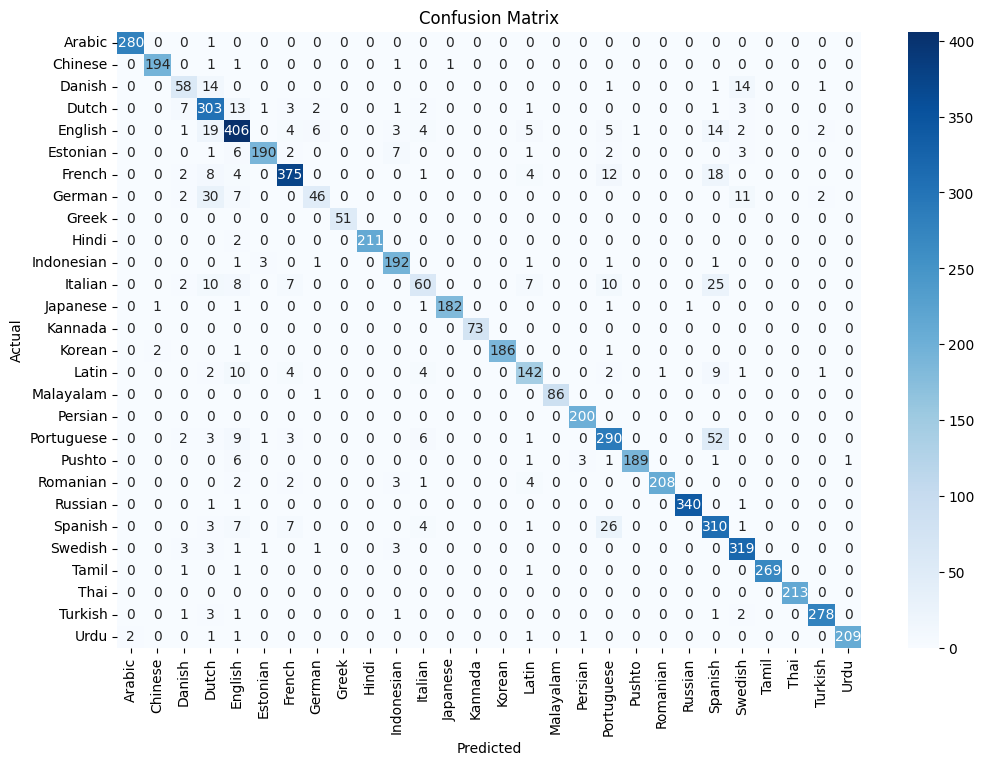

Language: Arabic
  Precision: 0.9929
  Recall: 0.9964
  F1-Score: 0.9947
------------------------------
Language: Chinese
  Precision: 0.9848
  Recall: 0.9798
  F1-Score: 0.9823
------------------------------
Language: Danish
  Precision: 0.7342
  Recall: 0.6517
  F1-Score: 0.6905
------------------------------
Language: Dutch
  Precision: 0.7519
  Recall: 0.8991
  F1-Score: 0.8189
------------------------------
Language: English
  Precision: 0.8303
  Recall: 0.8602
  F1-Score: 0.8450
------------------------------
Language: Estonian
  Precision: 0.9694
  Recall: 0.8962
  F1-Score: 0.9314
------------------------------
Language: French
  Precision: 0.9214
  Recall: 0.8844
  F1-Score: 0.9025
------------------------------
Language: German
  Precision: 0.8070
  Recall: 0.4694
  F1-Score: 0.5935
------------------------------
Language: Greek
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
------------------------------
Language: Hindi
  Precision: 1.0000
  Recall: 0.9906
  F1-Scor

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predicted labels for the test data
y_pred = np.argmax(model_nn.predict(X_test_pad), axis=1)

# Generate a classification report with precision, recall, and F1-score for each language
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=list(label_mapping.keys())))

# Generate the confusion matrix to see how well the model is classifying each language
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label_mapping.keys()),
            yticklabels=list(label_mapping.keys()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# check for individual class performance
# Here, we compute precision, recall, and F1-score for each class
precision_per_class = classification_report(y_test, y_pred, target_names=list(label_mapping.keys()), output_dict=True)

for language, metrics in precision_per_class.items():
    if language not in ['accuracy', 'macro avg', 'weighted avg']:
        print(f"Language: {language}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall: {metrics['recall']:.4f}")
        print(f"  F1-Score: {metrics['f1-score']:.4f}")
        print("-" * 30)


#  Long Short-Term Memory(LSTM) Model
The LSTM model is trained to capture sequential patterns in character-level text and improve language classification.

In [18]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense, Flatten

# Define the LSTM Neural Network model
num_classes = len(set(y_train))  # Number of unique classes in the dataset
model_lstm = Sequential(name="My_LSTM_Model",
    layers=[
        Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length, mask_zero=True),  # Embedding layer
        LSTM(128, return_sequences=False),  # LSTM layer
        Dropout(0.5),  # Dropout to prevent overfitting
        Dense(64, activation='relu'),  # Fully connected layer
        Dense(num_classes, activation='softmax')  # Output layer
    ]
)

# Model's name and parameters summary
print(f"Model Name: {model_lstm.name}")
model_lstm.summary()

# Compile the model
model_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training the LSTM model
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

# Evaluation of the model
loss, accuracy = model_lstm.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Model Name: My_LSTM_Model


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "My_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.4874 - loss: 1.5891 - val_accuracy: 0.6304 - val_loss: 1.0606
Epoch 2/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.6782 - loss: 0.9868 - val_accuracy: 0.7695 - val_loss: 0.6772
Epoch 3/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8011 - loss: 0.6090 - val_accuracy: 0.8508 - val_loss: 0.5016
Epoch 4/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8786 - loss: 0.4026 - val_accuracy: 0.9147 - val_loss: 0.3129
Epoch 5/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9063 - loss: 0.3296 - val_accuracy: 0.9300 - val_loss: 0.2573
Epoch 6/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9307 - loss: 0.2561 - val_accuracy: 0.9404 - val_loss: 0.2316
Epoch 7/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9425 - loss: 0.2161 - val_accuracy: 0.9477 - val_loss: 0.1987
Epoch 8/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9468 - loss: 0.2015 - 

# Save the LSTM Model

In [19]:
model_lstm.save('LSTM_Model.h5')
model_lstm.save('LSTM_Model.keras')
print("LSTM Model saved Successfully!")

LSTM Model saved Successfully!


# Performance of LSTM Model
The LSTM predictions are evaluated using precision, recall, F1-score, and a confusion matrix for each language.
The LSTM predictions are compared with the true test labels using class-level metrics and a confusion matrix.

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Classification Report:
               precision    recall  f1-score   support

      Arabic       0.99      1.00      0.99       281
     Chinese       0.97      0.99      0.98       198
      Danish       0.82      0.90      0.86        89
       Dutch       0.93      0.94      0.93       337
     English       0.89      0.95      0.92       472
    Estonian       0.98      0.88      0.93       212
      French       0.94      0.97      0.95       424
      German       0.87      0.81      0.84        98
       Greek       1.00      1.00      1.00        51
       Hindi       0.98      1.00      0.99       213
  Indonesian       0.93      0.97      0.95       200
     Italian       0.86      0.86      0.86       129
    Japanese       0.99      0.97      0.98       187
     Kannada       1.00      1.00      1.00        73
      Korean       1.00      0.98      0.99       190
       Latin       0.89      0.88      0.88       176
   Malayalam    

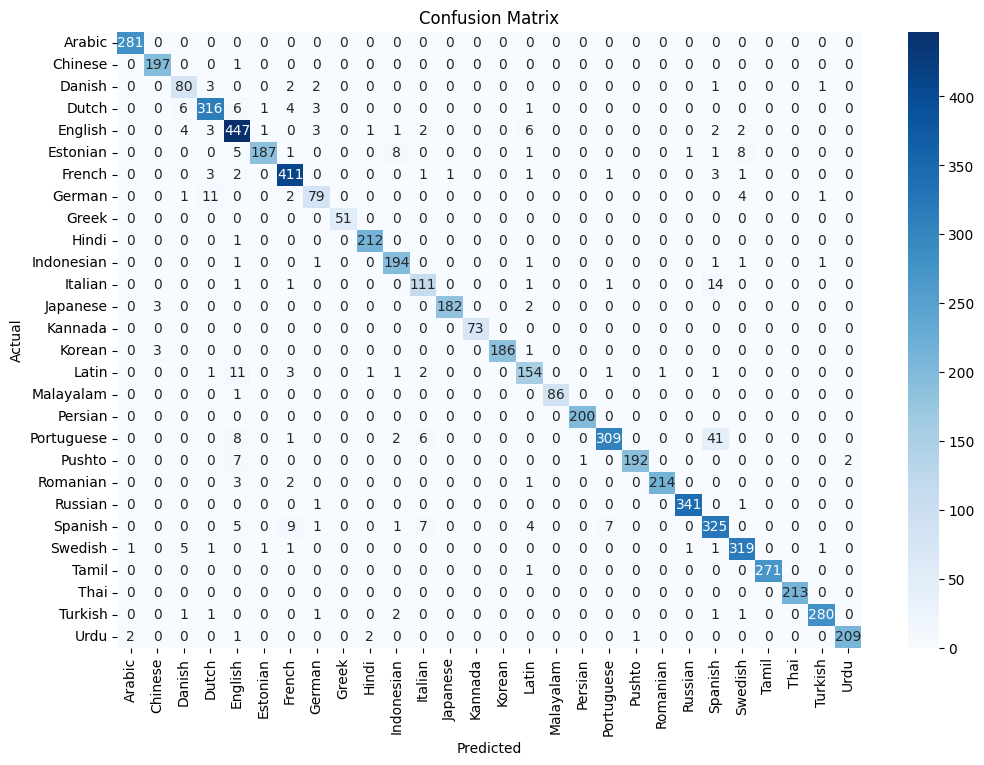

Language: Arabic
  Precision: 0.9894
  Recall: 1.0000
  F1-Score: 0.9947
------------------------------
Language: Chinese
  Precision: 0.9704
  Recall: 0.9949
  F1-Score: 0.9825
------------------------------
Language: Danish
  Precision: 0.8247
  Recall: 0.8989
  F1-Score: 0.8602
------------------------------
Language: Dutch
  Precision: 0.9322
  Recall: 0.9377
  F1-Score: 0.9349
------------------------------
Language: English
  Precision: 0.8940
  Recall: 0.9470
  F1-Score: 0.9198
------------------------------
Language: Estonian
  Precision: 0.9842
  Recall: 0.8821
  F1-Score: 0.9303
------------------------------
Language: French
  Precision: 0.9405
  Recall: 0.9693
  F1-Score: 0.9547
------------------------------
Language: German
  Precision: 0.8681
  Recall: 0.8061
  F1-Score: 0.8360
------------------------------
Language: Greek
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
------------------------------
Language: Hindi
  Precision: 0.9815
  Recall: 0.9953
  F1-Scor

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Language labels updated based on the label mapping
# top_preds_labels = [[list(label_mapping.keys())[list(label_mapping.values()).index(i)] for i in row] for row in top_preds]
Language_labels = list(label_mapping.keys())

# Get predicted labels for the test data
y_pred = np.argmax(model_lstm.predict(X_test_pad), axis=1)

# Generate a classification report with precision, recall, and F1-score for each language
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=Language_labels))

# Generate the confusion matrix to see how well the model is classifying each language
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=Language_labels,
            yticklabels=Language_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Check for individual class performance
# Here, we compute precision, recall, and F1-score for each class
precision_per_class = classification_report(y_test, y_pred, target_names=Language_labels, output_dict=True)

# Display precision, recall, and F1-score for each language
for language, metrics in precision_per_class.items():
    if language not in ['accuracy', 'macro avg', 'weighted avg']:
        print(f"Language: {language}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall: {metrics['recall']:.4f}")
        print(f"  F1-Score: {metrics['f1-score']:.4f}")
        print("-" * 30)


# Gated Recurrent Unit(GRU) Model

The GRU model learns sequential character patterns using a gated recurrent architecture. It is trained and evaluated using the same test setup as the other models.

In [21]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Dropout, GRU, Flatten

# Define the GRU model
num_classes = len(set(y_train))  # Number of unique classes in the dataset
model_gru = Sequential(name="My_GRU_Model",
    layers=[
        Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length, mask_zero=True),  # Embedding layer
        GRU(128, return_sequences=False),  # GRU layer with 128 units
        Dropout(0.5),  # Dropout to prevent overfitting
        Dense(64, activation='relu'),  # Fully connected layer
        Dense(num_classes, activation='softmax')  # Output layer
    ]
)

# Model's name and parameters summary
print(f"Model Name: {model_gru.name}")
model_gru.summary()

# Compile the model
model_gru.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training the GRU model
history_gru = model_gru.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

# Evaluation of the model
loss, accuracy = model_gru.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Model Name: My_GRU_Model


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "My_GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.6126 - loss: 1.2282 - val_accuracy: 0.8579 - val_loss: 0.4679
Epoch 2/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8878 - loss: 0.3880 - val_accuracy: 0.9256 - val_loss: 0.2586
Epoch 3/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9329 - loss: 0.2509 - val_accuracy: 0.9437 - val_loss: 0.2057
Epoch 4/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9464 - loss: 0.2069 - val_accuracy: 0.9519 - val_loss: 0.1901
Epoch 5/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9535 - loss: 0.1749 - val_accuracy: 0.9536 - val_loss: 0.1866
Epoch 6/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9598 - loss: 0.1508 - val_accuracy: 0.9617 - val_loss: 0.1613
Epoch 7/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9652 - loss: 0.1357 - val_accuracy: 0.9599 - val_loss: 0.1686
Epoch 8/10
804/804 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9677 - loss: 0.1214 - 

# Save GRU Model

In [22]:
model_gru.save('GRU_Model.h5')
model_gru.save('GRU_Model.keras')
print("GRU Model saved successfully!")

GRU Model saved successfully!


# Performance of GRU Model

The GRU predictions are evaluated using class-level metrics and a confusion matrix to examine classification performance.


201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Classification Report - GRU Model:
               precision    recall  f1-score   support

      Arabic       0.99      1.00      0.99       281
     Chinese       0.98      0.99      0.98       198
      Danish       0.99      0.87      0.92        89
       Dutch       0.94      0.95      0.94       337
     English       0.91      0.97      0.94       472
    Estonian       0.99      0.92      0.95       212
      French       0.96      0.99      0.97       424
      German       0.87      0.92      0.89        98
       Greek       1.00      1.00      1.00        51
       Hindi       0.99      1.00      0.99       213
  Indonesian       0.97      0.96      0.97       200
     Italian       0.87      0.91      0.89       129
    Japanese       1.00      0.97      0.99       187
     Kannada       1.00      1.00      1.00        73
      Korean       1.00      0.98      0.99       190
       Latin       0.95      0.89      0.92       176
   M

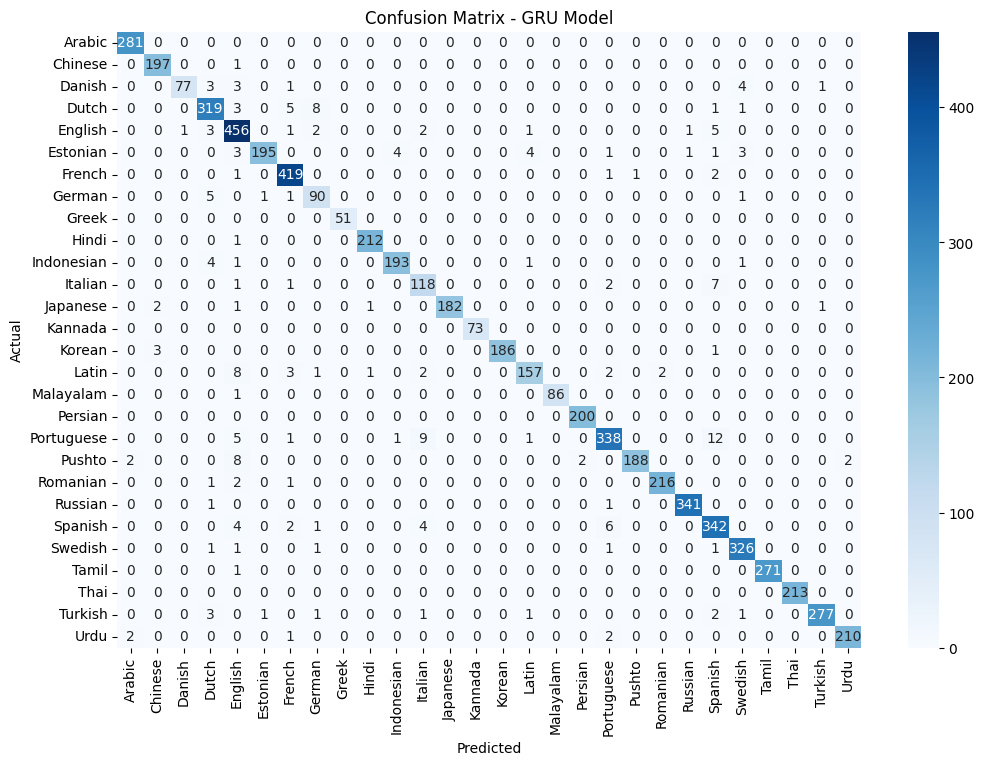

Language: Arabic
  Precision: 0.9860
  Recall: 1.0000
  F1-Score: 0.9929
------------------------------
Language: Chinese
  Precision: 0.9752
  Recall: 0.9949
  F1-Score: 0.9850
------------------------------
Language: Danish
  Precision: 0.9872
  Recall: 0.8652
  F1-Score: 0.9222
------------------------------
Language: Dutch
  Precision: 0.9382
  Recall: 0.9466
  F1-Score: 0.9424
------------------------------
Language: English
  Precision: 0.9102
  Recall: 0.9661
  F1-Score: 0.9373
------------------------------
Language: Estonian
  Precision: 0.9898
  Recall: 0.9198
  F1-Score: 0.9535
------------------------------
Language: French
  Precision: 0.9610
  Recall: 0.9882
  F1-Score: 0.9744
------------------------------
Language: German
  Precision: 0.8654
  Recall: 0.9184
  F1-Score: 0.8911
------------------------------
Language: Greek
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
------------------------------
Language: Hindi
  Precision: 0.9907
  Recall: 0.9953
  F1-Scor

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predicted labels for the test data using the GRU model
y_pred_gru = np.argmax(model_gru.predict(X_test_pad), axis=1)

# Generate a classification report with precision, recall, and F1-score for each language
print("Classification Report - GRU Model:\n",
      classification_report(y_test, y_pred_gru, target_names=Language_labels))

# Generate the confusion matrix to analyze classification performance
cm_gru = confusion_matrix(y_test, y_pred_gru)

# Plot the confusion matrix for the GRU model
plt.figure(figsize=(12, 8))
sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Blues',
            xticklabels=Language_labels,
            yticklabels=Language_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - GRU Model')
plt.show()

# Evaluate individual class performance
precision_per_class_gru = classification_report(
    y_test, y_pred_gru, target_names=Language_labels, output_dict=True
)

# Display precision, recall, and F1-score for each language
for language, metrics in precision_per_class_gru.items():
    if language not in ['accuracy', 'macro avg', 'weighted avg']:
        print(f"Language: {language}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall: {metrics['recall']:.4f}")
        print(f"  F1-Score: {metrics['f1-score']:.4f}")
        print("-" * 30)


# Comparision of Performances of NN , LSTM , GRU

This section brings the three models together to compare training behavior, prediction confidence, and overall test performance.

Training and validation curves show how each model learns over the epochs. Prediction-confidence distributions and test accuracy/loss are also collected for comparison.

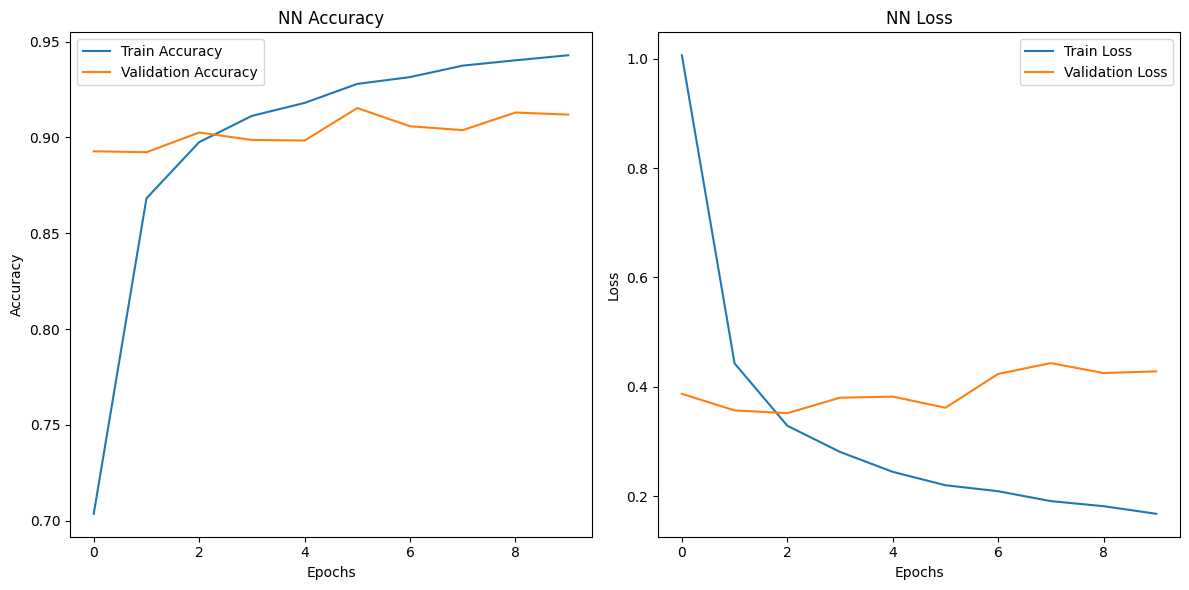

201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


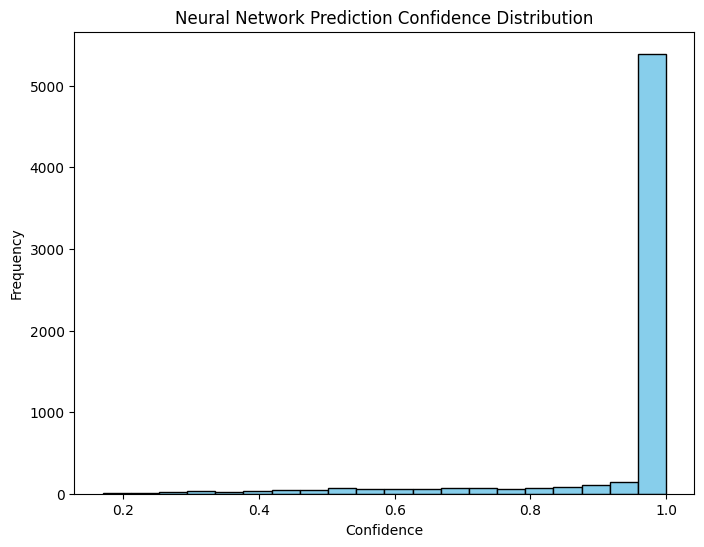

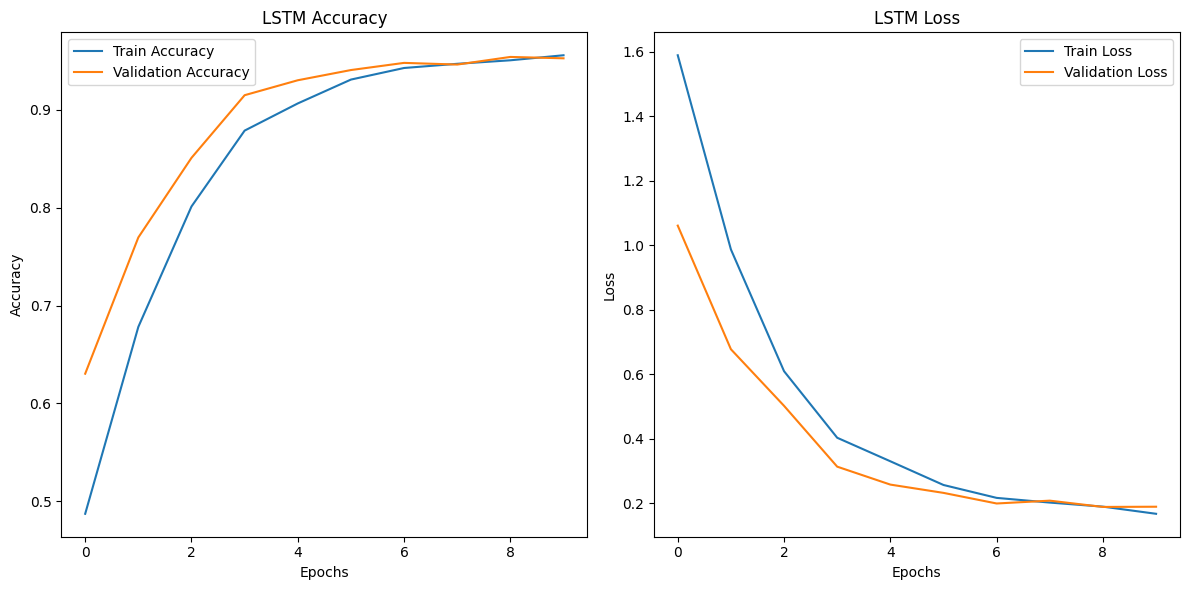

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


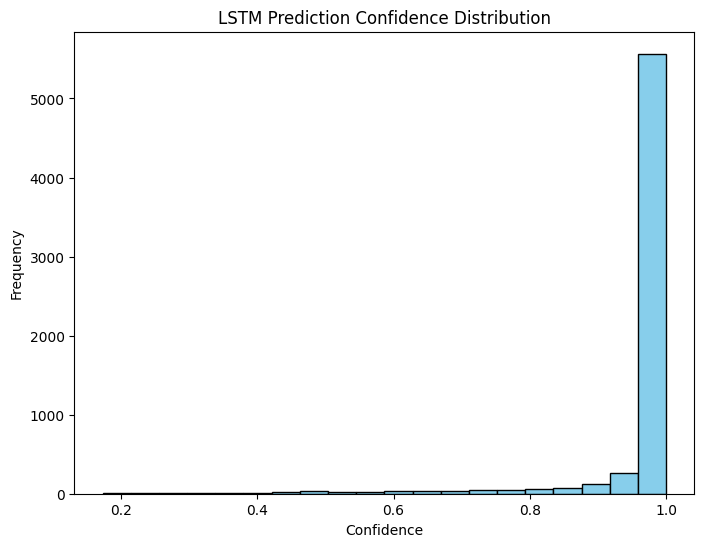

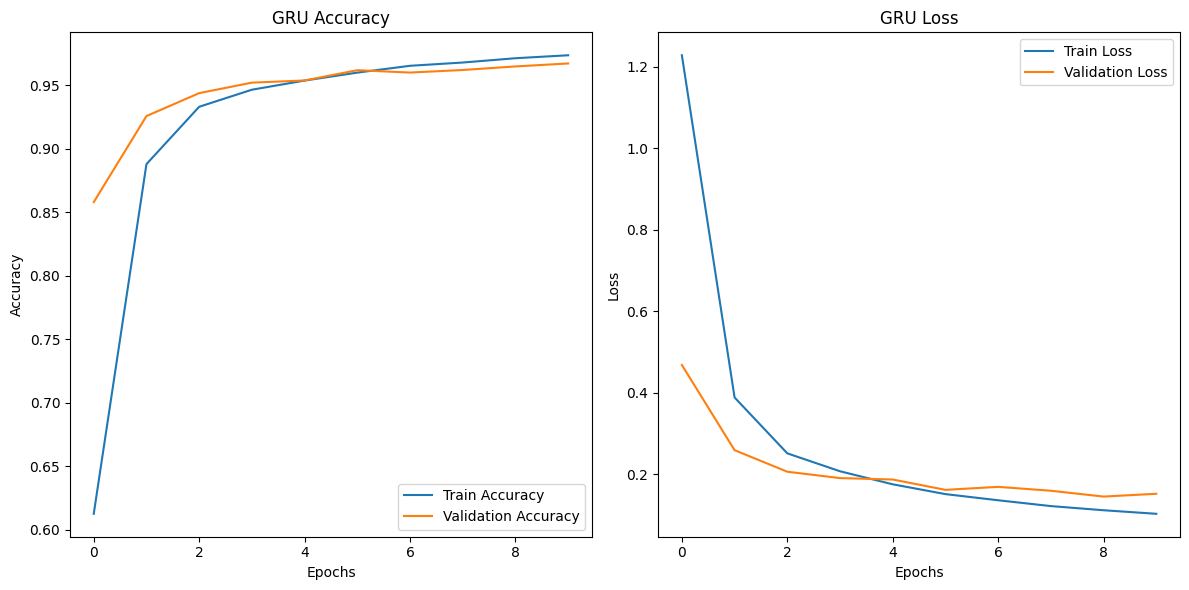

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


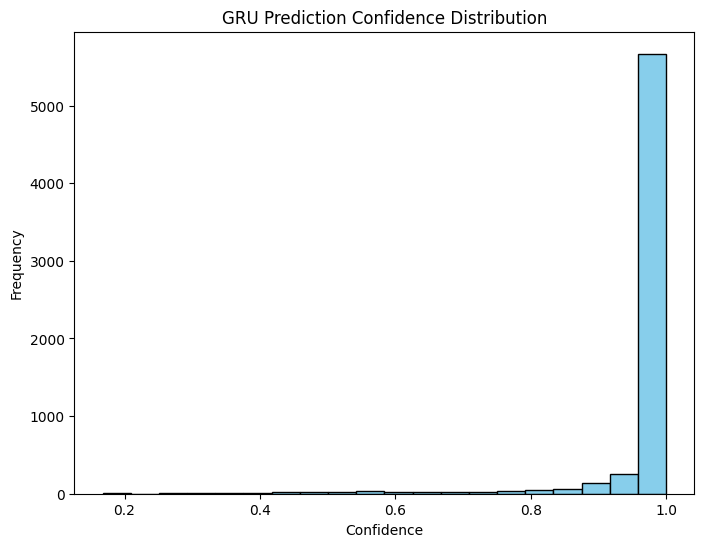


Summary Table:
| Model | Accuracy | Loss |
|-------|----------|------|
| Neural Network | 0.9119 | 0.4282 |
| LSTM | 0.9524 | 0.1887 |
| GRU | 0.9670 | 0.1516 |


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score

# Plot Training and Validation Accuracy and Loss
def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 6))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{model_name} Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Evaluate Model Performance
def evaluate_model(model, X_test, y_test):
    # Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    return accuracy, loss

# Confidence Distribution
def plot_confidence_distribution(model, title, X_test):
    y_pred_proba = model.predict(X_test)
    confidences = np.max(y_pred_proba, axis=1)
    plt.figure(figsize=(8, 6))
    plt.hist(confidences, bins=20, color='skyblue', edgecolor='black')
    plt.title(f'{title} Prediction Confidence Distribution')
    plt.xlabel('Confidence')
    plt.ylabel('Frequency')
    plt.show()

# Example Usage for Models
metrics = {}

# Neural Network
plot_training_history(history_nn, 'NN')
accuracy_nn, loss_nn = evaluate_model(model_nn, X_test_pad, y_test)
plot_confidence_distribution(model_nn, 'Neural Network', X_test_pad)
metrics['Neural Network'] = {'accuracy': accuracy_nn, 'loss': loss_nn}

# LSTM
plot_training_history(history_lstm, 'LSTM')
accuracy_lstm, loss_lstm = evaluate_model(model_lstm, X_test_pad, y_test)
plot_confidence_distribution(model_lstm, 'LSTM', X_test_pad)
metrics['LSTM'] = {'accuracy': accuracy_lstm, 'loss': loss_lstm}

# GRU
plot_training_history(history_gru, 'GRU')
accuracy_gru, loss_gru = evaluate_model(model_gru, X_test_pad, y_test)
plot_confidence_distribution(model_gru, 'GRU', X_test_pad)
metrics['GRU'] = {'accuracy': accuracy_gru, 'loss': loss_gru}

# Summary Table
print("\nSummary Table:")
print("| Model | Accuracy | Loss |")
print("|-------|----------|------|")
for name, metric in metrics.items():
    print(f"| {name} | {metric['accuracy']:.4f} | {metric['loss']:.4f} |")


### Final Evaluation

The models are compared using accuracy, macro F1-score, minimum class F1-score, parameter count, model size, inference time per sample, and accuracy on shorter inputs. These measures provide a broader view of performance and robustness.


In [25]:
import time, os, numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences

MODELS = [("NN", model_nn, "NN_Model.keras"),
          ("LSTM", model_lstm, "LSTM_Model.keras"),
          ("GRU", model_gru, "GRU_Model.keras")]

def predict_ids(m, texts):
    seq = tokenizer.texts_to_sequences(texts)
    pad = pad_sequences(seq, maxlen=max_length, padding='post')
    return np.argmax(m.predict(pad, batch_size=256, verbose=0), axis=1)

rows = []
for name, m, path in MODELS:
    t = time.time()
    p = np.argmax(m.predict(X_test_pad, batch_size=256, verbose=0), axis=1)
    ms = (time.time() - t) / len(X_test_pad) * 1000
    row = {"Model": name,
           "Accuracy": accuracy_score(y_test, p),
           "MacroF1": f1_score(y_test, p, average='macro'),
           "MinClassF1": f1_score(y_test, p, average=None).min(),
           "Params": m.count_params(),
           "SizeMB": os.path.getsize(path) / 1e6,
           "ms/sample": ms}
    # Robustness: only the first N characters of each test text
    for n in (20, 50, 100):
        row[f"Acc@{n}chars"] = accuracy_score(y_test, predict_ids(m, X_test.str[:n]))
    rows.append(row)

print(pd.DataFrame(rows).round(4).to_string(index=False))

Model  Accuracy  MacroF1  MinClassF1  Params  SizeMB  ms/sample  Acc@20chars  Acc@50chars  Acc@100chars
   NN    0.9119   0.9082      0.5660 2489564 29.9033     0.1111       0.4891       0.7017        0.8397
 LSTM    0.9524   0.9532      0.8360  990940 11.9258     0.0592       0.6844       0.8484        0.9241
  GRU    0.9670   0.9674      0.8906  958428 11.5356     0.0399       0.7082       0.8722        0.9435


In [26]:
import os, shutil
from google.colab import files

OUT = "LingualSense_outputs"
shutil.rmtree(OUT, ignore_errors=True)
os.makedirs(f"{OUT}/Data Files", exist_ok=True)
for d in ("NN", "LSTM", "GRU"):
    os.makedirs(f"{OUT}/{d}", exist_ok=True)

# (source file, destination folder)
FILES = [
    ("tokenizer.joblib",           "Data Files"),
    ("label_encoder.joblib",       "Data Files"),
    ("label_mapping.json",         "Data Files"),
    ("cleaned_encoded_dataset.csv","Data Files"),
    ("NN_Model.keras",             "NN"),
    ("NN_Model.h5",                "NN"),
    ("LSTM_Model.keras",           "LSTM"),
    ("LSTM_Model.h5",              "LSTM"),
    ("GRU_Model.keras",            "GRU"),
    ("GRU_Model.h5",               "GRU"),
]

for src, dest in FILES:
    if os.path.exists(src):
        shutil.copy(src, f"{OUT}/{dest}/{src}")
        print("added  :", src, "->", dest)
    else:
        print("MISSING:", src)

shutil.make_archive(OUT, "zip", OUT)
files.download(f"{OUT}.zip")

added  : tokenizer.joblib -> Data Files
added  : label_encoder.joblib -> Data Files
added  : label_mapping.json -> Data Files
added  : cleaned_encoded_dataset.csv -> Data Files
added  : NN_Model.keras -> NN
added  : NN_Model.h5 -> NN
added  : LSTM_Model.keras -> LSTM
added  : LSTM_Model.h5 -> LSTM
added  : GRU_Model.keras -> GRU
added  : GRU_Model.h5 -> GRU


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>